In [2]:
# Core
import pandas as pd
import numpy as np

# Viz
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Settings
sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("Placement_Data.csv")  # adjust path if needed

df.head()
df.shape

(215, 15)

In [4]:
df.info()
df.isnull().sum()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    str    
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    str    
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    str    
 6   hsc_s           215 non-null    str    
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    str    
 9   workex          215 non-null    str    
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    str    
 12  mba_p           215 non-null    float64
 13  status          215 non-null    str    
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), str(8)
memory usage: 35.0 KB


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
count,215.000000,215,215.000000,215,215.000000,215,215,215.000000,215,215,215.000000,215,215.000000,215,148.000000
unique,NaN,2,NaN,2,NaN,2,3,NaN,3,2,NaN,2,NaN,2,NaN
top,NaN,M,NaN,Central,NaN,Others,Commerce,NaN,Comm&Mgmt,No,NaN,Mkt&Fin,NaN,Placed,NaN
freq,NaN,139,NaN,116,NaN,131,113,NaN,145,141,NaN,120,NaN,148,NaN
mean,108.000000,NaN,67.303395,NaN,66.333163,NaN,NaN,66.370186,NaN,NaN,72.100558,NaN,62.278186,NaN,288655.405405
std,62.209324,NaN,10.827205,NaN,10.897509,NaN,NaN,7.358743,NaN,NaN,13.275956,NaN,5.833385,NaN,93457.452420
min,1.000000,NaN,40.890000,NaN,37.000000,NaN,NaN,50.000000,NaN,NaN,50.000000,NaN,51.210000,NaN,200000.000000
25%,54.500000,NaN,60.600000,NaN,60.900000,NaN,NaN,61.000000,NaN,NaN,60.000000,NaN,57.945000,NaN,240000.000000
50%,108.000000,NaN,67.000000,NaN,65.000000,NaN,NaN,66.000000,NaN,NaN,71.000000,NaN,62.000000,NaN,265000.000000
75%,161.500000,NaN,75.700000,NaN,73.000000,NaN,NaN,72.000000,NaN,NaN,83.500000,NaN,66.255000,NaN,300000.000000


In [5]:
# 1. Drop useless column
df = df.drop(columns=['sl_no'])

# 2. Handle salary properly
# Keep salary only for placed students
df['salary'] = df['salary'].fillna(0)

# 3. Convert target variable (VERY IMPORTANT)
df['status'] = df['status'].map({'Placed':1, 'Not Placed':0})

# 4. Convert categorical columns
df = pd.get_dummies(df, drop_first=True)

df.head()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,status,salary,gender_M,ssc_b_Others,hsc_b_Others,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,workex_Yes,specialisation_Mkt&HR
0,56.0,52.0,52.00,66.00,59.43,0,0.0,True,False,False,False,True,False,True,False,True
1,55.0,49.8,67.25,55.00,51.58,0,0.0,True,True,True,False,True,False,True,True,False
2,46.0,49.2,79.00,74.28,53.29,0,0.0,False,True,True,True,False,False,False,False,False
3,58.0,70.0,61.00,54.00,52.21,0,0.0,True,False,False,True,False,False,False,False,False
4,47.0,55.0,65.00,62.00,65.04,0,0.0,False,False,True,False,True,False,False,False,True


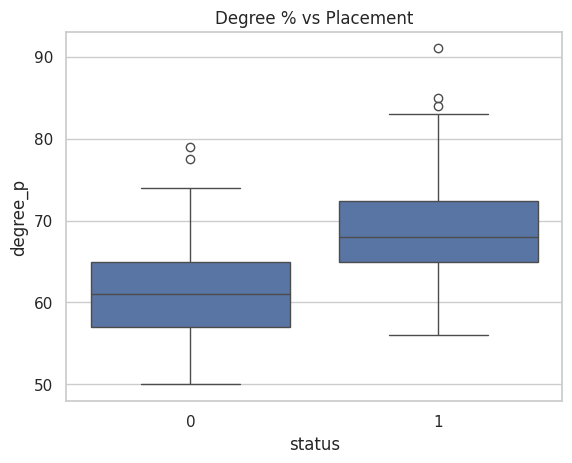

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='status', y='degree_p', data=df)
plt.title("Degree % vs Placement")
plt.show()

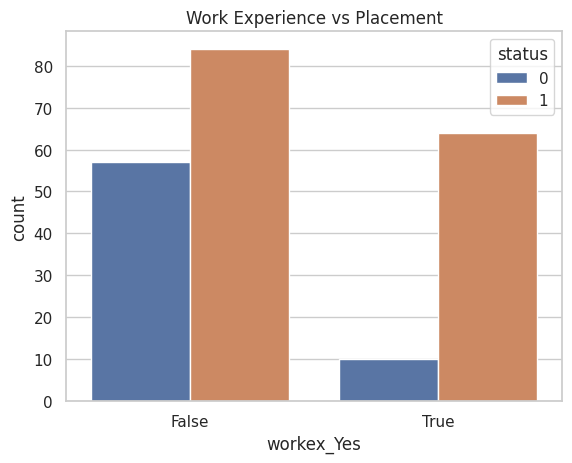

In [7]:
sns.countplot(x='workex_Yes', hue='status', data=df)
plt.title("Work Experience vs Placement")
plt.show()

In [8]:
pd.crosstab(df['workex_Yes'], df['status'], normalize='index') * 100

status,0,1
workex_Yes,,
False,40.425532,59.574468
True,13.513514,86.486486


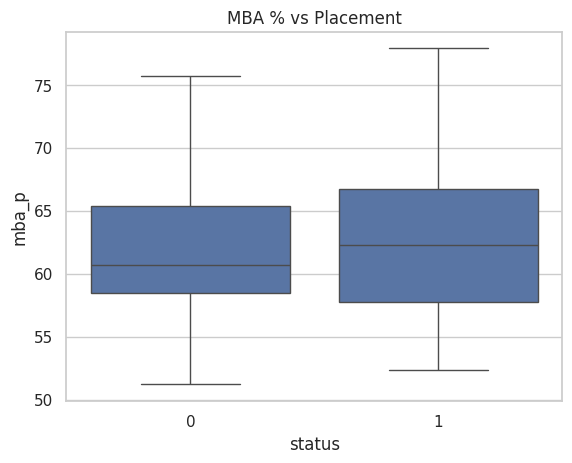

In [9]:
sns.boxplot(x='status', y='mba_p', data=df)
plt.title("MBA % vs Placement")
plt.show()

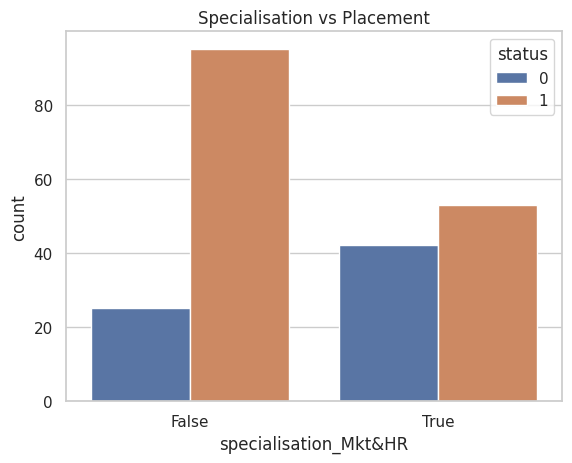

In [10]:
sns.countplot(x='specialisation_Mkt&HR', hue='status', data=df)
plt.title("Specialisation vs Placement")
plt.show()

In [11]:
pd.crosstab(df['specialisation_Mkt&HR'], df['status'], normalize='index') * 100

status,0,1
specialisation_Mkt&HR,,
False,20.833333,79.166667
True,44.210526,55.789474


In [12]:
pd.crosstab(df['gender_M'], df['status'], normalize='index') * 100

status,0,1
gender_M,,
False,36.842105,63.157895
True,28.057554,71.942446


In [13]:
from sklearn.model_selection import train_test_split

# Select features
X = df.drop(columns=['status', 'salary'])
y = df['status']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X.shape, X_train.shape, X_test.shape

((215, 14), (172, 14), (43, 14))

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8372093023255814

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.44      0.53         9
           1       0.86      0.94      0.90        34

    accuracy                           0.84        43
   macro avg       0.77      0.69      0.72        43
weighted avg       0.82      0.84      0.82        43


Confusion Matrix:
 [[ 4  5]
 [ 2 32]]


In [16]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7906976744186046

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.44      0.47         9
           1       0.86      0.88      0.87        34

    accuracy                           0.79        43
   macro avg       0.68      0.66      0.67        43
weighted avg       0.78      0.79      0.79        43


Confusion Matrix:
 [[ 4  5]
 [ 4 30]]


In [17]:
import pandas as pd

feature_names = df.drop(columns=['status', 'salary']).columns

importance = pd.Series(model.coef_[0], index=feature_names)
importance = importance.sort_values(ascending=False)

importance

ssc_p                    2.104693
hsc_p                    1.281376
degree_p                 1.121598
workex_Yes               0.628791
gender_M                 0.411189
ssc_b_Others             0.162966
hsc_b_Others             0.101295
etest_p                 -0.007984
degree_t_Others         -0.038727
specialisation_Mkt&HR   -0.196323
hsc_s_Science           -0.263254
degree_t_Sci&Tech       -0.683069
hsc_s_Commerce          -0.760022
mba_p                   -1.116728
dtype: float64

In [18]:
def generate_feedback(input_data):
    feedback = []

    if input_data['degree_p'] < 65:
        feedback.append("Improve your degree percentage to increase placement chances.")

    if input_data['workex_Yes'] == 0:
        feedback.append("Try to gain internship or work experience.")

    if input_data['specialisation_Mkt&HR'] == 1:
        feedback.append("Consider strengthening finance-related skills for better opportunities.")

    if input_data['ssc_p'] < 70:
        feedback.append("Strong academic consistency improves placement chances.")

    if not feedback:
        return "Your profile looks strong. Focus on interview preparation."

    return " ".join(feedback)

In [19]:
sample = {
    'degree_p': 60,
    'workex_Yes': 0,
    'specialisation_Mkt&HR': 1,
    'ssc_p': 65
}

print(generate_feedback(sample))

Improve your degree percentage to increase placement chances. Try to gain internship or work experience. Consider strengthening finance-related skills for better opportunities. Strong academic consistency improves placement chances.


In [20]:
import joblib

joblib.dump(model, "placement_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [21]:
feature_names = df.drop(columns=['status', 'salary']).columns
print(feature_names)

Index(['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'gender_M',
       'ssc_b_Others', 'hsc_b_Others', 'hsc_s_Commerce', 'hsc_s_Science',
       'degree_t_Others', 'degree_t_Sci&Tech', 'workex_Yes',
       'specialisation_Mkt&HR'],
      dtype='str')


In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

import joblib
joblib.dump(model, "placement_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [23]:
from sklearn.calibration import CalibratedClassifierCV

base = LogisticRegression(max_iter=1000, class_weight='balanced')
calibrated = CalibratedClassifierCV(base, method='sigmoid', cv=3)

calibrated.fit(X_train, y_train)

import joblib
joblib.dump(calibrated, "placement_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']